In [ ]:
!pip install ultralytics opencv-python-headless

Loading YOLOv8 AI Model...
 Processing video (192 frames). Visualizing first frame steps...


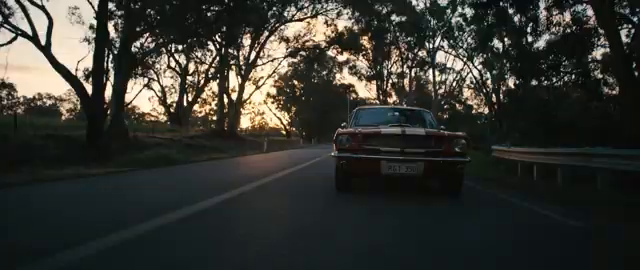

 Original Frame


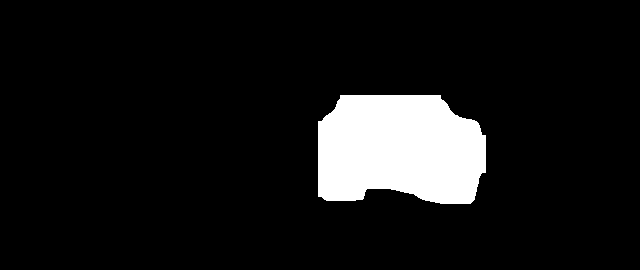

 Generated Mask (white areas indicate car)


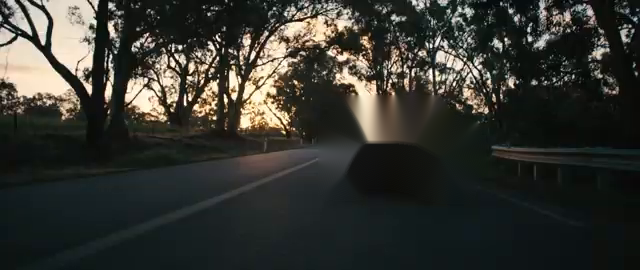

 Frame After Inpainting
 Processed 30 / 192 frames...
 Processed 60 / 192 frames...
 Processed 90 / 192 frames...
 Processed 120 / 192 frames...
 Processed 150 / 192 frames...
 Processed 180 / 192 frames...
 Done! You can now download: erased_car_output.mp4


In [ ]:
import cv2
import numpy as np
from ultralytics import YOLO
from IPython.display import Image, display # Import for displaying images in Colab

print("Loading YOLOv8 AI Model...")
# This downloads the segmentation model automatically
model = YOLO('yolov8n-seg.pt')

# File paths (make sure these match your uploaded file!)
input_video_path = 'car_video.mp4'
output_video_path = 'erased_car_output.mp4'

cap = cv2.VideoCapture(input_video_path)

if not cap.isOpened():
    print(f" Error: Could not open {input_video_path}. Did you upload it and rename it correctly?")
else:
    # Set up the Video Writer to save the new file
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

    print(f" Processing video ({total_frames} frames). Visualizing first frame steps...")

    frame_count = 0
    while cap.isOpened():
        success, frame = cap.read()
        if not success:
            break

        frame_count += 1

        # 1. Track the CAR (COCO Class 2)
        results = model.track(frame, classes=[2, 5, 7], conf=0.1, persist=True, verbose=False)
        mask = np.zeros(frame.shape[:2], dtype=np.uint8)

        # For the first frame, display intermediate steps
        if frame_count == 1:
            _, original_frame_encoded = cv2.imencode('.png', frame)
            display(Image(data=original_frame_encoded.tobytes()))
            print(" Original Frame")

        # 2. Extract and build the mask
        if results[0].masks is not None:
            for m in results[0].masks.data:
                m_resized = cv2.resize(m.cpu().numpy(), (width, height))
                mask = cv2.bitwise_or(mask, (m_resized * 255).astype(np.uint8))

            # Expand the mask to 25x25 to make sure we erase the car's shadow too!
            kernel = np.ones((25, 25), np.uint8)
            mask = cv2.dilate(mask, kernel, iterations=1)

            if frame_count == 1:
                # Display the mask (e.g., as a grayscale image)
                mask_colored = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR) # Convert mask to 3 channels for display
                _, mask_encoded = cv2.imencode('.png', mask_colored)
                display(Image(data=mask_encoded.tobytes()))
                print(" Generated Mask (white areas indicate car)")

            # 3. Erase the car using OpenCV Telea Inpainting
            frame = cv2.inpaint(frame, mask, 5, cv2.INPAINT_TELEA)

            if frame_count == 1:
                _, inpainted_frame_encoded = cv2.imencode('.png', frame)
                display(Image(data=inpainted_frame_encoded.tobytes()))
                print(" Frame After Inpainting")
        elif frame_count == 1:
            print(" No car detected in the first frame.")

        # Write the modified frame to the new video file
        out.write(frame)

        # Print progress to the console
        if frame_count % 30 == 0:
            print(f" Processed {frame_count} / {total_frames} frames...")

    # Cleanup
    cap.release()
    out.release()
    print(f" Done! You can now download: {output_video_path}")